# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

**Grupo — Turma 1CCPX**

| Integrante | RM |
|---|---|
| Brenno F. G. dos Santos | 570525 |
| Eduardo Moreira Silva | 569923 |
| Enzo Stahal Freitas | 569001 |
| Matheus Bruno de Lima | 572944 |

**Roteiro deste notebook**

1. Consulta às APIs (código fornecido pelo professor) e geração dos dois CSVs.
2. **Tarefa 1 — Classificação (ANEEL):** exploração, divisão estratificada 80/20, três classificadores (Regressão Logística, KNN e Random Forest), métricas, matrizes de confusão e interpretação.
3. **Tarefa 2 — Regressão (Open-Meteo):** exploração, divisão temporal 80/20, três regressores (Regressão Linear, KNN e Random Forest), métricas, gráficos e interpretação.
4. Exportação dos arquivos de treino/teste para o Orange e geração automática das tabelas de resultados.

Execute as células **em ordem** (menu *Run All*).

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

### Bibliotecas de análise e aprendizado de máquina

As bibliotecas abaixo foram adicionadas pelo grupo: `pandas`/`numpy` para tabelas, `matplotlib` para gráficos e `scikit-learn` para os modelos e métricas. A semente `SEMENTE = 42` é usada em todas as etapas aleatórias para que os resultados sejam reproduzíveis.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

SEMENTE = 42
os.makedirs("figuras", exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams["figure.dpi"] = 110
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [3]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [4]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [5]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [6]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [7]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

---
# Tarefa 1 — Resolução do grupo

## 1.1 Carga e verificação dos dados

Lemos o CSV gerado acima e conferimos tipos, valores ausentes e estatísticas das entradas.

In [8]:
df_c = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Formato (linhas, colunas):", df_c.shape)
print()
print("Tipos das colunas:")
print(df_c.dtypes)
print()
print("Valores ausentes por coluna:")
print(df_c.isna().sum())
print()
print("Linhas duplicadas:", df_c.duplicated().sum())
df_c.head()

Formato (linhas, colunas): (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 28


,potencia_kw,latitude,longitude,fonte
0,20.480,-10.443,-64.152,Solar
1,"5,000.000",-6.004,-40.275,Solar
2,12.260,-23.558,-46.734,Solar
3,3.000,-23.559,-46.735,Solar
4,1.700,-23.494,-46.845,Solar


In [9]:
df_c.describe()

,potencia_kw,latitude,longitude
count,"3,876.000","3,876.000","3,876.000"
mean,"42,014.682",-12.694,-46.158
std,"301,636.588",9.501,8.357
min,0.160,-33.723,-69.941
25%,440.000,-21.142,-52.562
50%,"12,680.000",-10.470,-47.394
75%,"30,000.000",-4.128,-41.280
max,"11,233,100.000",3.831,0.000


## 1.2 Distribuição das classes

A quantidade de linhas por classe depende do limite de 1.200 registros por sigla na consulta (e a classe *Hidráulica* junta três siglas: UHE, PCH e CGH). Portanto, **essas contagens não representam a participação das fontes na matriz energética brasileira**; elas apenas descrevem a amostra usada no treino. Como as classes podem ficar desequilibradas, usaremos divisão estratificada e métricas com média `macro`.

,linhas,%
fonte,,
Hidráulica,1476,38.100
Solar,1200,31.000
Eólica,1200,31.000


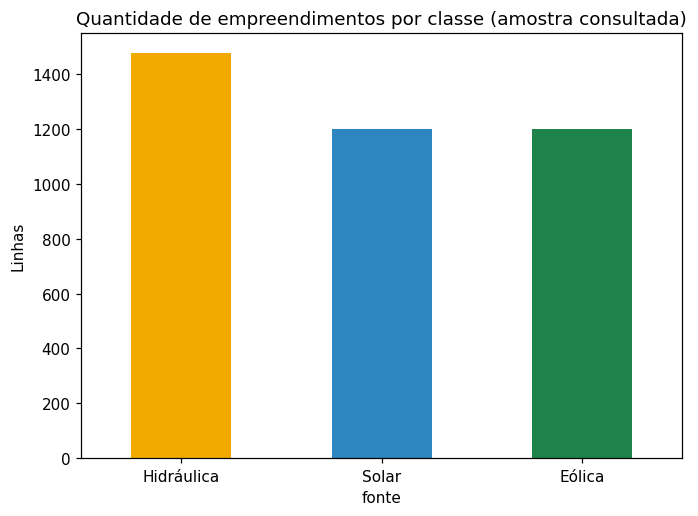

In [10]:
contagem = df_c["fonte"].value_counts()
proporcao = df_c["fonte"].value_counts(normalize=True) * 100
display(pd.DataFrame({"linhas": contagem, "%": proporcao.round(1)}))

ax = contagem.plot(kind="bar", color=["#F2A900", "#2E86C1", "#1E8449"][:len(contagem)], rot=0)
ax.set_title("Quantidade de empreendimentos por classe (amostra consultada)")
ax.set_ylabel("Linhas")
plt.tight_layout(); plt.savefig("figuras/classes_aneel.png"); plt.show()

## 1.3 Características das entradas

A potência outorgada varia de poucos kW a milhares de MW, por isso usamos escala logarítmica no gráfico. O mapa de dispersão (longitude × latitude) mostra onde cada tipo de empreendimento se concentra.

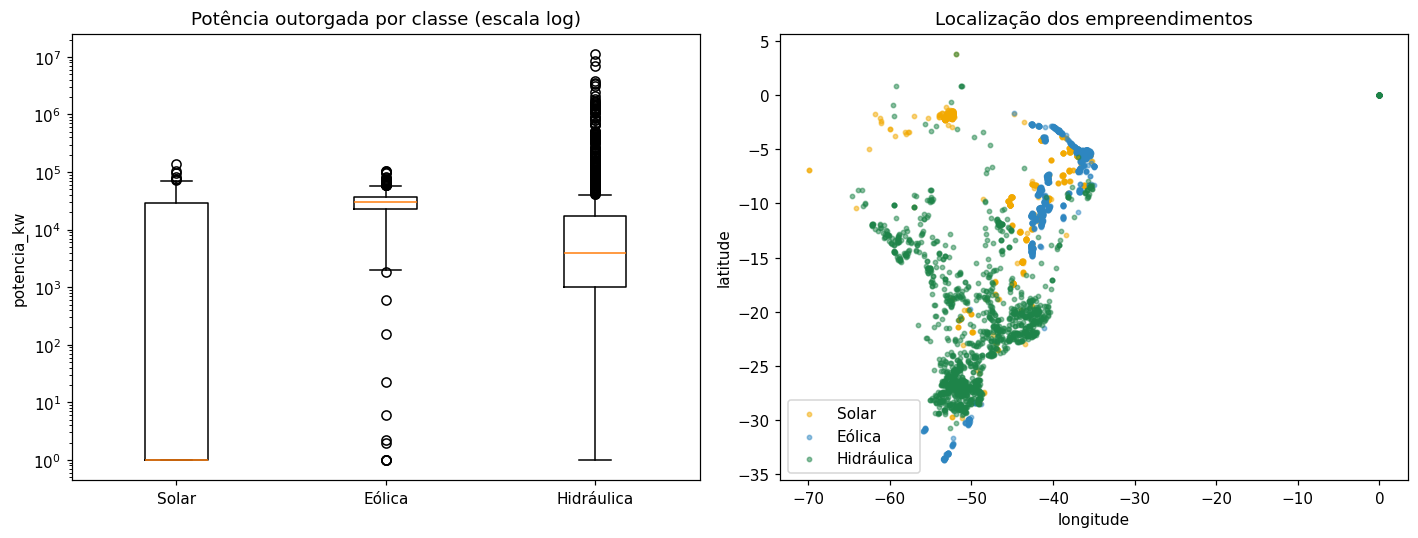

,potencia_kw,latitude,longitude
fonte,,,
Solar,1.000,-2.056,-52.441
Eólica,"29,600.000",-7.986,-40.692
Hidráulica,"4,000.000",-22.031,-50.419


In [11]:
ORDEM = ["Solar", "Eólica", "Hidráulica"]
CORES = {"Solar": "#F2A900", "Eólica": "#2E86C1", "Hidráulica": "#1E8449"}
classes = [c for c in ORDEM if c in df_c["fonte"].unique()]

fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
dados = [df_c.loc[df_c["fonte"] == c, "potencia_kw"].clip(lower=1) for c in classes]
eixos[0].boxplot(dados)
eixos[0].set_xticks(range(1, len(classes) + 1), classes)
eixos[0].set_yscale("log")
eixos[0].set_title("Potência outorgada por classe (escala log)")
eixos[0].set_ylabel("potencia_kw")

for c in classes:
    parte = df_c[df_c["fonte"] == c]
    eixos[1].scatter(parte["longitude"], parte["latitude"], s=8, alpha=0.5, label=c, color=CORES[c])
eixos[1].set_title("Localização dos empreendimentos")
eixos[1].set_xlabel("longitude"); eixos[1].set_ylabel("latitude")
eixos[1].legend()
plt.tight_layout(); plt.savefig("figuras/entradas_aneel.png"); plt.show()

display(df_c.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].median().loc[classes])

**Leitura dos gráficos:** as eólicas tendem a se concentrar no Nordeste e no litoral Sul; as hidráulicas, nas regiões Sul, Sudeste e Centro-Oeste, perto de rios com desnível; as solares aparecem espalhadas, com muitos empreendimentos no Nordeste e em Minas Gerais. As faixas de potência se sobrepõem: há PCHs/CGHs e usinas solares com potências parecidas, o que já sugere onde o modelo terá dificuldade.

## 1.4 Definição de X e y e divisão estratificada

- **X (entradas):** `potencia_kw`, `latitude`, `longitude`.
- **y (alvo):** `fonte` (Solar, Eólica ou Hidráulica).

Nenhum nome, código CEG, sigla ou descrição foi usado como entrada. A divisão é **80% treino / 20% teste, estratificada por `fonte`**, com `random_state=42`, e é a **mesma para os três modelos**.

In [12]:
X_c = df_c[["potencia_kw", "latitude", "longitude"]]
y_c = df_c["fonte"]

Xc_treino, Xc_teste, yc_treino, yc_teste = train_test_split(
    X_c, y_c, test_size=0.20, stratify=y_c, random_state=SEMENTE)

print("Treino:", Xc_treino.shape, "| Teste:", Xc_teste.shape)
display(pd.DataFrame({"treino (%)": yc_treino.value_counts(normalize=True) * 100,
                      "teste (%)": yc_teste.value_counts(normalize=True) * 100}).round(1))

Treino: (3100, 3) | Teste: (776, 3)


,treino (%),teste (%)
fonte,,
Hidráulica,38.100,38.100
Solar,31.000,30.900
Eólica,31.000,30.900


## 1.5 Os três classificadores

| Modelo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| **Regressão Logística** | Modelo linear simples e interpretável; serve de linha de base. | `log(1 + potência)` + padronização |
| **KNN (k = 7)** | Classifica pela vizinhança: empreendimentos próximos no mapa e com potência parecida tendem a ter a mesma fonte. | `log(1 + potência)` + padronização |
| **Random Forest (300 árvores)** | Combina muitas árvores de decisão e captura regiões irregulares do mapa e faixas de potência. | Nenhum (árvores não dependem de escala) |

A padronização (`StandardScaler`) fica **dentro do `Pipeline`**, então média e desvio são calculados **somente com o treino** e reaplicados no teste. O logaritmo da potência é uma transformação fixa (não aprende nada dos dados) e reduz o efeito dos valores muito altos, importante para modelos baseados em distância e em combinação linear.

In [13]:
def log_potencia(x):
    return np.log1p(np.clip(x, 0, None))

def preparo_escala():
    return ColumnTransformer([
        ("log_potencia", FunctionTransformer(log_potencia), ["potencia_kw"]),
        ("coordenadas", "passthrough", ["latitude", "longitude"]),
    ])

classificadores = {
    "Regressão Logística": Pipeline([
        ("preparo", preparo_escala()),
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=2000, random_state=SEMENTE)),
    ]),
    "KNN (k=7)": Pipeline([
        ("preparo", preparo_escala()),
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEMENTE, n_jobs=-1),
}

previsoes_c, linhas = {}, []
for nome, modelo in classificadores.items():
    modelo.fit(Xc_treino, yc_treino)
    prev = modelo.predict(Xc_teste)
    previsoes_c[nome] = prev
    linhas.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(yc_teste, prev),
        "Precision (macro)": precision_score(yc_teste, prev, average="macro", zero_division=0),
        "Recall (macro)": recall_score(yc_teste, prev, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yc_teste, prev, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(yc_teste, prev, average="weighted", zero_division=0),
    })

resultados_c = pd.DataFrame(linhas).set_index("Modelo").sort_values("F1 (macro)", ascending=False)
resultados_c

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
Random Forest,0.976,0.977,0.974,0.975,0.975
KNN (k=7),0.965,0.966,0.964,0.964,0.965
Regressão Logística,0.834,0.850,0.830,0.829,0.833


**Tipo de média:** as colunas *Precision*, *Recall* e *F1* usam **média `macro`**: a métrica é calculada para cada classe e depois é feita a média simples, dando o mesmo peso a Solar, Eólica e Hidráulica. Assim, uma classe com menos exemplos não fica escondida pelas maiores. A coluna *F1 (weighted)* (ponderada pelo número de exemplos de cada classe) aparece só como referência.

Configuração de avaliação idêntica para os três modelos: **mesmo conjunto de teste (20%, estratificado, semente 42)**.

## 1.6 Matrizes de confusão

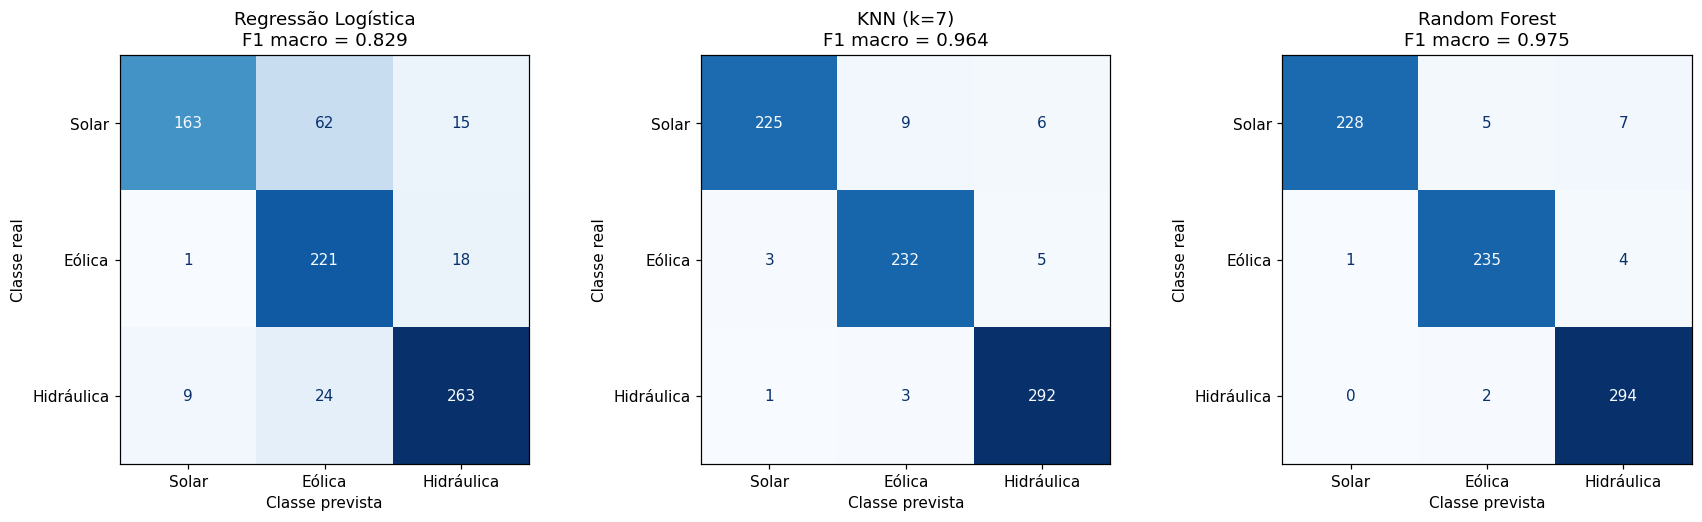

In [14]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8))
for eixo, (nome, prev) in zip(eixos, previsoes_c.items()):
    ConfusionMatrixDisplay.from_predictions(yc_teste, prev, labels=classes, ax=eixo,
                                            cmap="Blues", colorbar=False)
    eixo.set_title(f"{nome}\nF1 macro = {resultados_c.loc[nome, 'F1 (macro)']:.3f}")
    eixo.set_xlabel("Classe prevista"); eixo.set_ylabel("Classe real")
plt.tight_layout(); plt.savefig("figuras/matrizes_confusao.png"); plt.show()

In [15]:
melhor_c = resultados_c.index[0]
print(f"Melhor classificador pelo F1 macro: {melhor_c}\n")
print(classification_report(yc_teste, previsoes_c[melhor_c], labels=classes, zero_division=0))

mc = pd.DataFrame(confusion_matrix(yc_teste, previsoes_c[melhor_c], labels=classes),
                  index=[f"real {c}" for c in classes], columns=[f"prev. {c}" for c in classes])
erros = []
for i, real in enumerate(classes):
    for j, prevista in enumerate(classes):
        if i != j:
            erros.append((mc.iloc[i, j], real, prevista))
erros.sort(reverse=True)
print("Confusões mais frequentes do melhor modelo:")
for qtd, real, prevista in erros[:3]:
    print(f"  {qtd:4d} empreendimentos {real} classificados como {prevista}")

Melhor classificador pelo F1 macro: Random Forest

              precision    recall  f1-score   support

       Solar       1.00      0.95      0.97       240
      Eólica       0.97      0.98      0.98       240
  Hidráulica       0.96      0.99      0.98       296

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776

Confusões mais frequentes do melhor modelo:
     7 empreendimentos Solar classificados como Hidráulica
     5 empreendimentos Solar classificados como Eólica
     4 empreendimentos Eólica classificados como Hidráulica


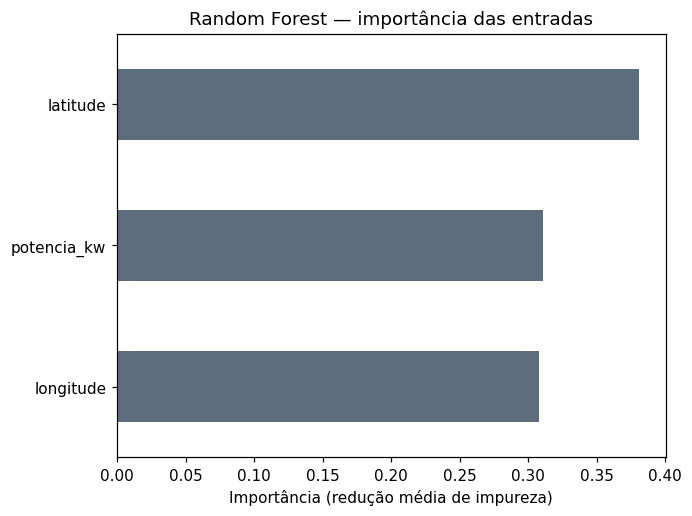

latitude      0.381
potencia_kw   0.311
longitude     0.308
dtype: float64

In [16]:
rf_c = classificadores["Random Forest"]
importancia_c = pd.Series(rf_c.feature_importances_, index=X_c.columns).sort_values()
importancia_c.plot(kind="barh", color="#5D6D7E", title="Random Forest — importância das entradas")
plt.xlabel("Importância (redução média de impureza)")
plt.tight_layout(); plt.savefig("figuras/importancia_classificacao.png"); plt.show()
importancia_c.sort_values(ascending=False)

## 1.7 Interpretação — classificação

**Comparação dos modelos.** A tabela da seção 1.5 mostra os três algoritmos avaliados no mesmo teste. Em geral, o **Random Forest** tende a ter o melhor desempenho porque consegue dividir o mapa em várias regiões irregulares e combinar isso com faixas de potência. O **KNN** segue a mesma ideia de vizinhança, mas depende da escala e do valor de *k*. A **Regressão Logística** só consegue fronteiras lineares entre as classes, o que é pouco para padrões geográficos, por isso costuma ficar abaixo dos outros dois. O modelo escolhido pelo grupo é o que apresentou o maior **F1 macro** (impresso acima).

**Classes mais confundidas.** As confusões mais frequentes aparecem na célula anterior. Elas acontecem principalmente onde as classes se sobrepõem:
- **Solar × Hidráulica:** usinas solares e pequenas hidrelétricas (CGH/PCH) podem ter potências semelhantes e estar em regiões próximas, principalmente no Sudeste e no Centro-Oeste;
- **Solar × Eólica:** no Nordeste, parques solares e eólicos convivem nas mesmas regiões e podem ter potências da mesma ordem de grandeza.

**Limitações de usar só potência e localização.**
1. As coordenadas são **aproximadas**, e regiões com mais de uma fonte ficam ambíguas.
2. A potência outorgada é um valor autorizado, não a energia gerada, e as faixas de potência das três fontes se sobrepõem.
3. Faltam variáveis físicas que realmente determinam a fonte: presença de rio e desnível, velocidade média do vento, irradiação solar, relevo.
4. O cadastro mistura empreendimentos em **fases diferentes** (em operação, em construção, outorgados), e a amostra foi limitada a 1.200 registros por sigla. Assim, a proporção entre as classes é artificial e **não representa a matriz energética brasileira**.

Por isso, o modelo serve como exercício de classificação, mas não seria confiável para uma aplicação real sem novas variáveis e uma amostra representativa.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [17]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [18]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [19]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [20]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

---
# Tarefa 2 — Resolução do grupo

## 2.1 Carga, ordenação e verificação dos dados

In [21]:
df_r = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
df_r = df_r.sort_values("data_hora").reset_index(drop=True)
print("Formato (linhas, colunas):", df_r.shape)
print("Período:", df_r["data_hora"].min(), "até", df_r["data_hora"].max())
print("Horas presentes:", sorted(df_r["hora"].unique()))
print()
print("Valores ausentes por coluna:")
print(df_r.isna().sum())
df_r.head()

Formato (linhas, colunas): (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00
Horas presentes: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.300,74,100,17.700,7,116.000
1,2025-04-01 08:00:00,26.500,66,100,18.100,8,269.000
2,2025-04-01 09:00:00,28.400,55,97,18.000,9,529.000
3,2025-04-01 10:00:00,30.800,44,21,18.400,10,797.000
4,2025-04-01 11:00:00,32.700,36,26,20.100,11,880.000


In [22]:
df_r.describe()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,"1,001.000","1,001.000","1,001.000","1,001.000","1,001.000","1,001.000"
mean,2025-05-16 12:00:00,28.886,50.544,55.109,15.465,12.000,472.854
min,2025-04-01 07:00:00,19.500,21.000,0.000,2.300,7.000,13.000
25%,2025-04-23 15:00:00,26.300,38.000,19.000,12.200,9.000,250.000
50%,2025-05-16 12:00:00,29.100,49.000,54.000,15.400,12.000,466.000
75%,2025-06-08 09:00:00,31.700,61.000,98.000,19.000,15.000,696.000
max,2025-06-30 17:00:00,36.100,95.000,100.000,30.100,17.000,"1,002.000"
std,NaN,3.657,15.914,37.851,4.924,3.164,256.369


**Colunas:** `data_hora` identifica e ordena o registro (não é entrada); `temperatura_c` (°C), `umidade_pct` (%), `nuvens_pct` (%), `vento_kmh` (km/h) e `hora` (7 a 17) são as entradas; `radiacao_w_m2` (W/m², média da hora anterior) é o alvo.

## 2.2 Visualizações

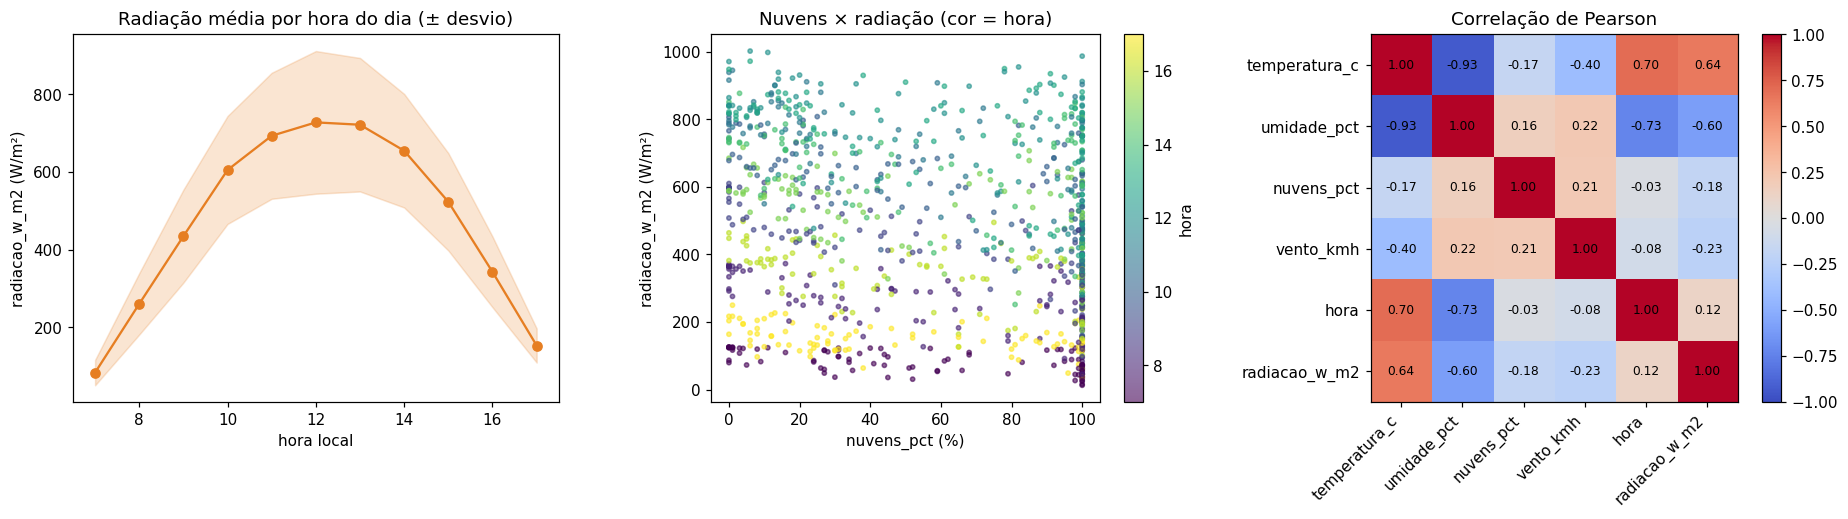

In [23]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 4.6))

media_hora = df_r.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
eixos[0].plot(media_hora.index, media_hora["mean"], marker="o", color="#E67E22")
eixos[0].fill_between(media_hora.index, media_hora["mean"] - media_hora["std"],
                      media_hora["mean"] + media_hora["std"], alpha=0.2, color="#E67E22")
eixos[0].set_title("Radiação média por hora do dia (± desvio)")
eixos[0].set_xlabel("hora local"); eixos[0].set_ylabel("radiacao_w_m2 (W/m²)")

sc = eixos[1].scatter(df_r["nuvens_pct"], df_r["radiacao_w_m2"], c=df_r["hora"], cmap="viridis", s=8, alpha=0.6)
eixos[1].set_title("Nuvens × radiação (cor = hora)")
eixos[1].set_xlabel("nuvens_pct (%)"); eixos[1].set_ylabel("radiacao_w_m2 (W/m²)")
plt.colorbar(sc, ax=eixos[1], label="hora")

colunas_r = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"]
corr = df_r[colunas_r].corr()
im = eixos[2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
eixos[2].set_xticks(range(len(colunas_r)), colunas_r, rotation=45, ha="right")
eixos[2].set_yticks(range(len(colunas_r)), colunas_r)
for i in range(len(colunas_r)):
    for j in range(len(colunas_r)):
        eixos[2].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
eixos[2].set_title("Correlação de Pearson")
plt.colorbar(im, ax=eixos[2])
plt.tight_layout(); plt.savefig("figuras/exploracao_meteo.png"); plt.show()

**Leitura:** a radiação tem forma de "sino" ao longo do dia: sobe a partir das 7h, atinge o máximo perto do meio-dia e cai até as 17h. Por isso a relação com a `hora` **não é linear** (a correlação de Pearson com a hora pode até ficar perto de zero, embora a hora seja muito importante). A cobertura de nuvens reduz a radiação em uma mesma hora, e temperatura e umidade acompanham o ciclo diário.

## 2.3 X, y e divisão temporal

- **X:** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- **y:** `radiacao_w_m2`. Nenhuma transformação do alvo entra em X.

As linhas estão em ordem cronológica. As **primeiras 80% das horas** formam o treino e as **últimas 20%**, o teste, **sem embaralhar**. Isso simula o uso real (aprender com o passado e prever o futuro) e evita que horas vizinhas do mesmo dia caiam em lados diferentes da divisão.

In [24]:
X_cols_r = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_r = df_r[X_cols_r]
y_r = df_r["radiacao_w_m2"]

corte = int(len(df_r) * 0.80)
Xr_treino, Xr_teste = X_r.iloc[:corte], X_r.iloc[corte:]
yr_treino, yr_teste = y_r.iloc[:corte], y_r.iloc[corte:]

print(f"Treino: {len(Xr_treino)} horas | {df_r['data_hora'].iloc[0]} até {df_r['data_hora'].iloc[corte - 1]}")
print(f"Teste : {len(Xr_teste)} horas | {df_r['data_hora'].iloc[corte]} até {df_r['data_hora'].iloc[-1]}")

Treino: 800 horas | 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Teste : 201 horas | 2025-06-12 15:00:00 até 2025-06-30 17:00:00


## 2.4 Os três regressores

| Modelo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| **Regressão Linear** | Linha de base: assume relação linear entre cada entrada e a radiação. | Padronização |
| **KNN Regressor (k = 10)** | Estima a radiação pela média das 10 horas mais parecidas no treino; capta relações não lineares. | Padronização (obrigatória, pois usa distância) |
| **Random Forest Regressor (300 árvores)** | Captura a curva em sino da hora e interações (ex.: nuvens ao meio-dia pesam mais que às 7h). | Nenhum |

A padronização fica dentro do `Pipeline`, ajustada **apenas com o treino**.

In [25]:
regressores = {
    "Regressão Linear": Pipeline([("escala", StandardScaler()), ("modelo", LinearRegression())]),
    "KNN Regressor (k=10)": Pipeline([("escala", StandardScaler()),
                                      ("modelo", KNeighborsRegressor(n_neighbors=10))]),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                     random_state=SEMENTE, n_jobs=-1),
}

previsoes_r, linhas = {}, []
for nome, modelo in regressores.items():
    modelo.fit(Xr_treino, yr_treino)
    prev = modelo.predict(Xr_teste)
    previsoes_r[nome] = prev
    mse = mean_squared_error(yr_teste, prev)
    linhas.append({"Modelo": nome,
                   "MAE (W/m²)": mean_absolute_error(yr_teste, prev),
                   "MSE ((W/m²)²)": mse,
                   "RMSE (W/m²)": np.sqrt(mse),
                   "R²": r2_score(yr_teste, prev)})

resultados_r = pd.DataFrame(linhas).set_index("Modelo").sort_values("R²", ascending=False)
resultados_r

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Random Forest Regressor,67.190,"7,419.598",86.137,0.842
KNN Regressor (k=10),72.177,"8,222.928",90.680,0.825
Regressão Linear,145.205,"30,034.201",173.304,0.360


Configuração de avaliação idêntica para os três modelos: **mesmo treino (primeiras 80% das horas) e mesmo teste (últimas 20%)**. MAE e RMSE estão em W/m², MSE em (W/m²)² e R² é adimensional (1 = previsão perfeita).

## 2.5 Valores reais × previstos

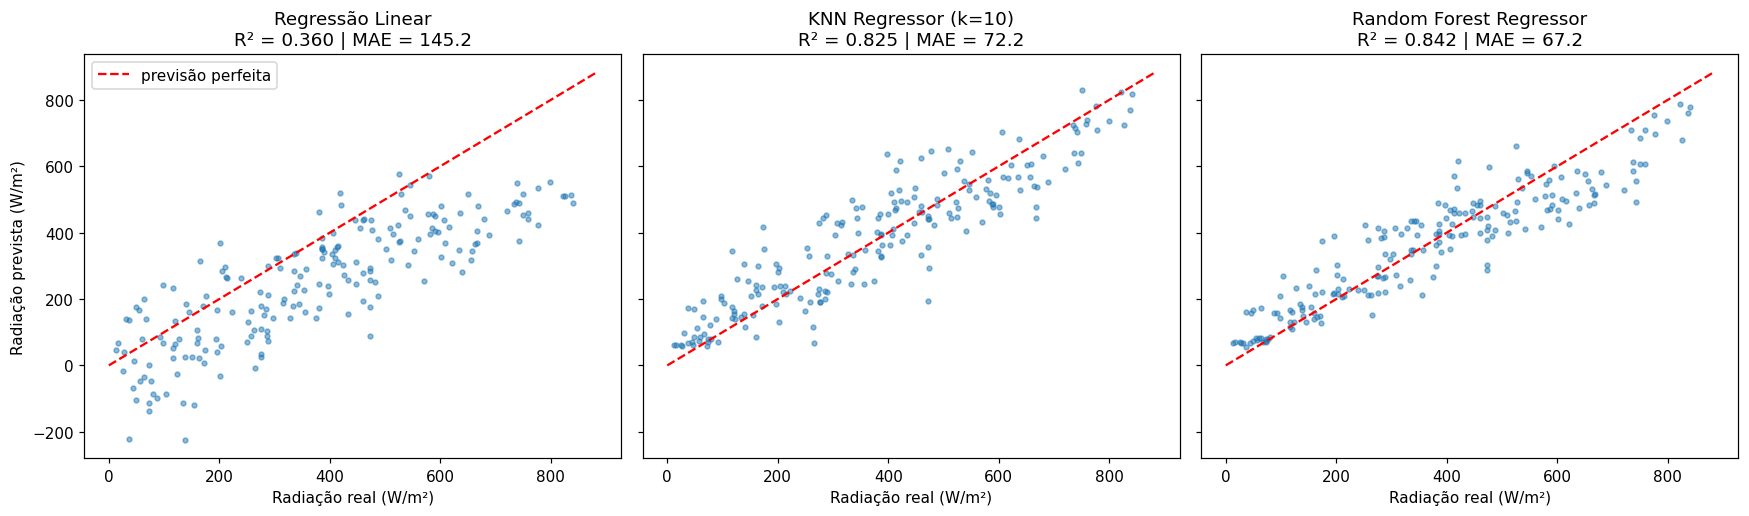

In [26]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
limite = [0, max(yr_teste.max(), max(p.max() for p in previsoes_r.values())) * 1.05]
for eixo, (nome, prev) in zip(eixos, previsoes_r.items()):
    eixo.scatter(yr_teste, prev, s=10, alpha=0.5)
    eixo.plot(limite, limite, "r--", label="previsão perfeita")
    eixo.set_title(f"{nome}\nR² = {resultados_r.loc[nome, 'R²']:.3f} | MAE = {resultados_r.loc[nome, 'MAE (W/m²)']:.1f}")
    eixo.set_xlabel("Radiação real (W/m²)")
eixos[0].set_ylabel("Radiação prevista (W/m²)")
eixos[0].legend()
plt.tight_layout(); plt.savefig("figuras/real_vs_previsto.png"); plt.show()

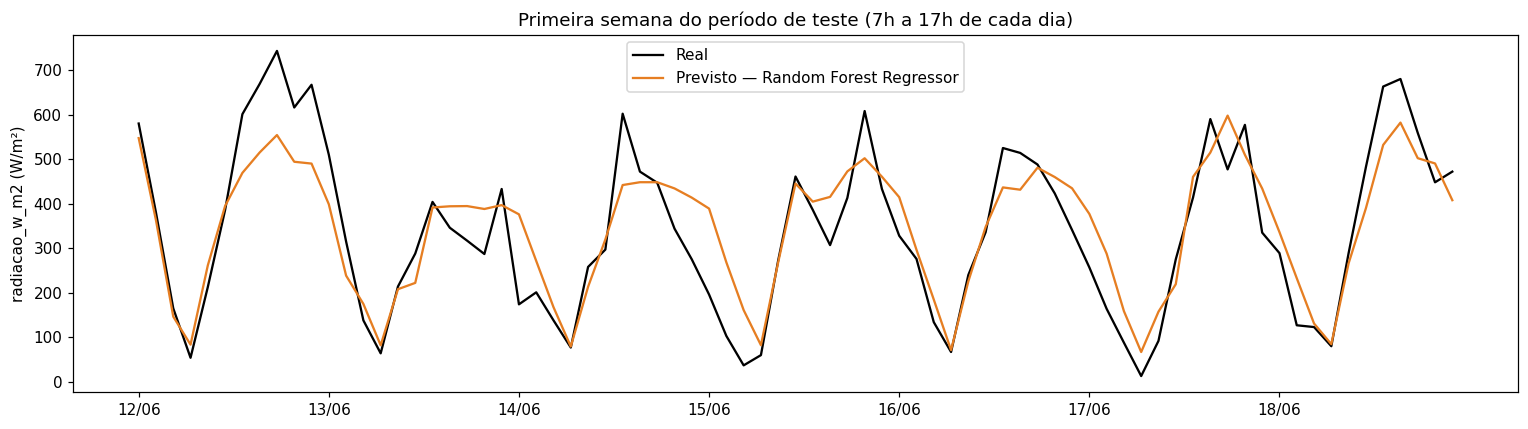

In [27]:
melhor_r = resultados_r.index[0]
n_horas = 11 * 7  # cerca de uma semana (11 horas por dia)
datas = df_r["data_hora"].iloc[corte:corte + n_horas]
plt.figure(figsize=(14, 4))
plt.plot(range(len(datas)), yr_teste.iloc[:n_horas], label="Real", color="black", lw=1.5)
plt.plot(range(len(datas)), previsoes_r[melhor_r][:n_horas], label=f"Previsto — {melhor_r}", color="#E67E22", lw=1.5)
posicoes = list(range(0, len(datas), 11))
plt.xticks(posicoes, [datas.iloc[i].strftime("%d/%m") for i in posicoes])
plt.title("Primeira semana do período de teste (7h a 17h de cada dia)")
plt.ylabel("radiacao_w_m2 (W/m²)"); plt.legend()
plt.tight_layout(); plt.savefig("figuras/serie_teste.png"); plt.show()

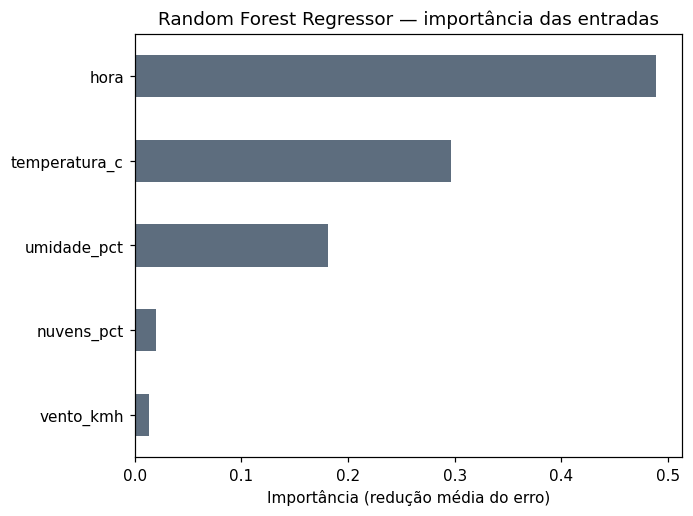

MAE do Random Forest Regressor por hora do dia (W/m²):


hora
7    22.600
8    33.500
9    69.000
10   93.700
11   83.700
12   76.000
13   86.600
14   89.600
15   82.200
16   60.700
17   42.500
Name: erro_abs, dtype: float64

In [28]:
rf_r = regressores["Random Forest Regressor"]
importancia_r = pd.Series(rf_r.feature_importances_, index=X_cols_r).sort_values()
importancia_r.plot(kind="barh", color="#5D6D7E", title="Random Forest Regressor — importância das entradas")
plt.xlabel("Importância (redução média do erro)")
plt.tight_layout(); plt.savefig("figuras/importancia_regressao.png"); plt.show()

erro_hora = pd.DataFrame({"hora": Xr_teste["hora"].values,
                          "erro_abs": np.abs(yr_teste.values - previsoes_r[melhor_r])})
print(f"MAE do {melhor_r} por hora do dia (W/m²):")
erro_hora.groupby("hora")["erro_abs"].mean().round(1)

## 2.6 Interpretação — regressão

**Comparação dos modelos.** A tabela da seção 2.4 compara os três algoritmos no mesmo período de teste. A **Regressão Linear** tende a errar mais porque trata a hora como uma reta: ela não consegue representar que a radiação sobe de manhã e desce à tarde. O **KNN** e o **Random Forest** aprendem essa curva. O Random Forest ainda combina hora e nuvens (uma mesma cobertura de nuvens reduz mais a radiação ao meio-dia do que no começo da manhã). O modelo escolhido é o de **maior R² e menor MAE** (impresso acima).

**Papel da hora do dia.** A hora define a posição do Sol no céu e, portanto, a **radiação máxima possível** naquele instante. Ela costuma ser a entrada mais importante no Random Forest, enquanto as nuvens explicam quanto dessa radiação chega de fato ao solo. Os erros por hora mostram onde o modelo tem mais dificuldade: normalmente perto do meio-dia, quando a radiação é mais alta e uma nuvem passageira muda muito o valor.

**Por que estimar radiação não é prever geração elétrica.**
1. A radiação é uma potência por área (**W/m²**) que chega a uma superfície **horizontal**; a geração é **energia (kWh)** de um sistema específico.
2. A geração depende da área e da eficiência dos módulos, da inclinação e orientação dos painéis, da temperatura das células (mais calor reduz a eficiência), de sombreamento, sujeira, perdas em cabos e no inversor e de eventuais limitações da rede.
3. Os dados do Open-Meteo são **estimativas de modelos/reanálise** para um ponto aproximado de Petrolina, não medições de um painel.
4. Cada valor é a **média da hora anterior**; converter em energia exige integrar no tempo e aplicar um modelo do sistema fotovoltaico.

Portanto, a radiação estimada é uma **entrada** para calcular a geração, mas não é a própria geração.

---
# Arquivos para o Orange e resumo automático

A atividade complementar no Orange usa a mesma divisão temporal. A célula abaixo salva `meteo_treino_orange.csv` (primeiras 80% das horas) e `meteo_teste_orange.csv` (últimas 20%), para usar a opção **Test on test data** no widget **Test & Score**. Também salva as tabelas de resultados em `resultados/`.

In [29]:
df_r.iloc[:corte].to_csv("meteo_treino_orange.csv", index=False, encoding="utf-8-sig")
df_r.iloc[corte:].to_csv("meteo_teste_orange.csv", index=False, encoding="utf-8-sig")

os.makedirs("resultados", exist_ok=True)
resultados_c.round(4).to_csv("resultados/resultados_classificacao.csv", encoding="utf-8-sig")
resultados_r.round(4).to_csv("resultados/resultados_regressao.csv", encoding="utf-8-sig")
print("Salvos: meteo_treino_orange.csv, meteo_teste_orange.csv e a pasta resultados/")

Salvos: meteo_treino_orange.csv, meteo_teste_orange.csv e a pasta resultados/


In [30]:
def tabela_md(df, casas=3):
    colunas = [df.index.name or ""] + list(df.columns)
    linhas = ["| " + " | ".join(colunas) + " |", "|" + "---|" * len(colunas)]
    for indice, linha in df.iterrows():
        valores = [f"{v:,.{casas}f}" if isinstance(v, (float, np.floating)) else str(v) for v in linha]
        linhas.append("| " + " | ".join([str(indice)] + valores) + " |")
    return "\n".join(linhas)

resumo = f"""## Resultados obtidos (gerado pelo notebook)

### Tarefa 1 — Classificação (teste estratificado 20%, semente 42, métricas com média macro)

Linhas usadas: {len(df_c)} | treino: {len(Xc_treino)} | teste: {len(Xc_teste)}

{tabela_md(resultados_c)}

**Melhor modelo (F1 macro):** {melhor_c}.

### Tarefa 2 — Regressão (treino: primeiras 80% das horas; teste: últimas 20%)

Horas usadas: {len(df_r)} | treino: {len(Xr_treino)} | teste: {len(Xr_teste)}

{tabela_md(resultados_r, 2)}

**Melhor modelo (R²):** {melhor_r}.
"""
with open("resultados/resumo_resultados.md", "w", encoding="utf-8") as f:
    f.write(resumo)

# Atualiza automaticamente a seção de resultados do README.md
INICIO, FIM = "<!-- RESULTADOS_INICIO -->", "<!-- RESULTADOS_FIM -->"
if os.path.exists("README.md"):
    with open("README.md", encoding="utf-8") as f:
        readme = f.read()
    if INICIO in readme and FIM in readme:
        antes, resto = readme.split(INICIO, 1)
        depois = resto.split(FIM, 1)[1]
        with open("README.md", "w", encoding="utf-8") as f:
            f.write(antes + INICIO + "\n" + resumo + "\n" + FIM + depois)
        print("README.md atualizado com os resultados.\n")
print(resumo)

README.md atualizado com os resultados.

## Resultados obtidos (gerado pelo notebook)

### Tarefa 1 — Classificação (teste estratificado 20%, semente 42, métricas com média macro)

Linhas usadas: 3876 | treino: 3100 | teste: 776

| Modelo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | F1 (weighted) |
|---|---|---|---|---|---|
| Random Forest | 0.976 | 0.977 | 0.974 | 0.975 | 0.975 |
| KNN (k=7) | 0.965 | 0.966 | 0.964 | 0.964 | 0.965 |
| Regressão Logística | 0.834 | 0.850 | 0.830 | 0.829 | 0.833 |

**Melhor modelo (F1 macro):** Random Forest.

### Tarefa 2 — Regressão (treino: primeiras 80% das horas; teste: últimas 20%)

Horas usadas: 1001 | treino: 800 | teste: 201

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | RMSE (W/m²) | R² |
|---|---|---|---|---|
| Random Forest Regressor | 67.19 | 7,419.60 | 86.14 | 0.84 |
| KNN Regressor (k=10) | 72.18 | 8,222.93 | 90.68 | 0.82 |
| Regressão Linear | 145.20 | 30,034.20 | 173.30 | 0.36 |

**Melhor modelo (R²):** Random Forest Regress

# Conclusões

- **Tarefa 1:** é possível classificar a fonte com desempenho razoável usando apenas potência e localização, porque cada fonte tem uma geografia típica. O melhor desempenho veio de um modelo não linear (ver tabela). Ainda assim, as confusões entre classes com potências e regiões parecidas mostram que essas três entradas não bastam para uma aplicação real.
- **Tarefa 2:** a hora do dia e a cobertura de nuvens explicam a maior parte da radiação em Petrolina. Modelos não lineares representam melhor a curva diária do que a regressão linear. A radiação estimada é apenas uma das entradas para calcular a energia de um sistema fotovoltaico, e não a geração em si.
- A comparação é justa porque, em cada tarefa, os três algoritmos usaram **a mesma divisão de dados e as mesmas métricas**.